# Task 6 - Categorical Analysis

**Gate 2 deliverable: Categorical-analysis method.**

Combines the categorical work from `notebooks/ella-zou/Categorical Analysis/ella_zou_task_6.ipynb`
and `notebooks/jonathan-deng/jonathan_deng_task_6.ipynb`.

Frozen artifacts, written next to this notebook:

| File | Contents |
| --- | --- |
| `categorical_inventory.csv` | one row per `cat*` field |
| `categorical_level_target_tables.csv` | one row per (field, level) |

Every headline statistic is reported in raw `loss` units. `log1p(loss)` is used
for plot readability only and never replaces the original target.

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root():
    path = Path.cwd().resolve()

    for parent in [path, *path.parents]:
        if (parent / "data" / "allstate_claims_data.csv").exists():
            return parent

    raise FileNotFoundError("Could not find data/allstate_claims_data.csv")


REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "data" / "allstate_claims_data.csv"
OUTPUT_DIR = REPO_ROOT / "notebooks" / "final-deliverables" / "September" / "Gate 2"

INVENTORY_PATH = OUTPUT_DIR / "categorical_inventory.csv"
LEVEL_TABLES_PATH = OUTPUT_DIR / "categorical_level_target_tables.csv"

CAT_COLS = [f"cat{i}" for i in range(1, 117)]
TARGET = "loss"

df = pd.read_csv(DATA_PATH)

print(f"Source:  {DATA_PATH.relative_to(REPO_ROOT)}")
print(f"Outputs: {OUTPUT_DIR.relative_to(REPO_ROOT)}")
print(f"Rows: {len(df):,} | categorical fields: {len(CAT_COLS)}")

Source:  data/allstate_claims_data.csv
Outputs: notebooks/final-deliverables/September/Gate 2
Rows: 188,318 | categorical fields: 116


## Rare-level threshold

Declared and frozen **before** any high-cardinality plot is interpreted.

In [2]:
THRESHOLD = 188

# EDA display and support rule: flag any level supported by fewer than 188 claims,
# which is approximately 0.1% of the 188,318 rows.
#
# Rationale: summary statistics computed from very small groups are unstable, so
# levels below this support are reported separately rather than read alongside
# well-supported levels.
#
# This is a display and support rule only. It is not an instruction to remove
# data: no row and no level is dropped anywhere in this notebook.

print(f"Rare-level threshold: fewer than {THRESHOLD} claims "
      f"({THRESHOLD / len(df):.3%} of rows)")

Rare-level threshold: fewer than 188 claims (0.100% of rows)


## Cardinality

How many levels each `cat*` field has, plus the starting checks the milestones
document specifies for this dataset.

In [3]:
n_levels = df[CAT_COLS].nunique()

cardinality_counts = (
    n_levels.value_counts()
    .sort_index()
    .rename_axis("levels_per_field")
    .reset_index(name="number_of_fields")
)

print("Fields by number of observed levels:")
print(cardinality_counts.to_string(index=False))

starting_checks = pd.Series({
    "72 fields have 2 observed levels": int((n_levels == 2).sum()) == 72,
    "88 fields have at most 4 observed levels": int((n_levels <= 4).sum()) == 88,
    "cat116 has 326 levels": int(n_levels["cat116"]) == 326,
    "cat110 has 131 levels": int(n_levels["cat110"]) == 131,
    "cat109 has 84 levels": int(n_levels["cat109"]) == 84,
})

display(starting_checks.to_frame("passed"))
assert starting_checks.all(), f"failed: {list(starting_checks[~starting_checks].index)}"

Fields by number of observed levels:
 levels_per_field  number_of_fields
                2                72
                3                 4
                4                12
                5                 3
                7                 4
                8                 3
                9                 1
               11                 1
               13                 1
               15                 1
               16                 2
               17                 2
               19                 2
               20                 2
               23                 1
               51                 1
               61                 1
               84                 1
              131                 1
              326                 1


,passed
72 fields have 2 observed levels,True
88 fields have at most 4 observed levels,True
cat116 has 326 levels,True
cat110 has 131 levels,True
cat109 has 84 levels,True


## Categorical-field inventory

One row per field. `least_common_support` and `min_support` are equal by
construction; both are reported because the requirement lists least-common
support and minimum support separately.

In [4]:
rows = []
for field in CAT_COLS:
    counts = df[field].value_counts()
    rare = counts[counts < THRESHOLD]

    rows.append({
        "field": field,
        "n_levels": int(counts.size),
        "most_common_level": counts.index[0],
        "most_common_support": int(counts.iloc[0]),
        "most_common_share": float(counts.iloc[0] / len(df)),
        "least_common_level": counts.index[-1],
        "least_common_support": int(counts.iloc[-1]),
        "min_support": int(counts.min()),
        "median_support": float(counts.median()),
        "n_rare_levels": int(rare.size),
        "rare_row_share": float(rare.sum() / len(df)),
    })

inventory = pd.DataFrame(rows)

print(f"Inventory covers {len(inventory)} of {len(CAT_COLS)} categorical fields")
print(f"Fields with at least one rare level: {(inventory['n_rare_levels'] > 0).sum()}")
print(f"Fields where one level holds over 99% of rows: "
      f"{(inventory['most_common_share'] > 0.99).sum()}")

display(inventory.sort_values("n_levels", ascending=False).head(10))

Inventory covers 116 of 116 categorical fields
Fields with at least one rare level: 39
Fields where one level holds over 99% of rows: 31


,field,n_levels,most_common_level,most_common_support,most_common_share,least_common_level,least_common_support,min_support,median_support,n_rare_levels,rare_row_share
115,cat116,326,HK,21061,0.111837,AE,1,1,35.0,223,0.035435
109,cat110,131,CL,25305,0.134374,S,1,1,29.0,92,0.015484
108,cat109,84,BI,152918,0.812020,AK,1,1,36.0,71,0.014821
112,cat113,61,BM,26191,0.139079,AR,1,1,1463.0,20,0.002055
111,cat112,51,E,25148,0.133540,AQ,30,30,1331.0,2,0.000924
114,cat115,23,K,43866,0.232936,C,1,1,315.0,9,0.000988
106,cat107,20,F,47310,0.251224,S,2,2,1432.0,8,0.002554
104,cat105,20,E,76493,0.406191,S,1,1,158.0,11,0.002623
100,cat101,19,A,106721,0.566706,U,1,1,2762.0,8,0.001731
113,cat114,19,A,131693,0.699312,G,1,1,250.0,8,0.000499


## Level-to-target tables

Support, raw mean loss, raw median loss, standard deviation, quartiles, and
interquartile range for every level of every field. Rare levels are flagged,
never filtered.

In [5]:
def level_target_table(field):
    grouped = df.groupby(field, observed=True)[TARGET]

    table = pd.DataFrame({
        "support": grouped.size(),
        "mean_loss": grouped.mean(),
        "median_loss": grouped.median(),
        "std_loss": grouped.std(),
        "q25_loss": grouped.quantile(0.25),
        "q75_loss": grouped.quantile(0.75),
    })
    table["iqr_loss"] = table["q75_loss"] - table["q25_loss"]
    table["is_rare"] = table["support"] < THRESHOLD

    return table.sort_values("support", ascending=False)


display(level_target_table("cat1"))

,support,mean_loss,median_loss,std_loss,q25_loss,q75_loss,iqr_loss,is_rare
cat1,,,,,,,,
A,141550,3408.091515,2458.69,3122.436629,1378.375,4407.1100,3028.7350,False
B,46768,1915.198521,1444.86,1666.082337,916.960,2331.1275,1414.1675,False


### Freeze the artifacts

In [6]:
all_tables = []
for field in CAT_COLS:
    table = level_target_table(field).reset_index().rename(columns={field: "level"})
    table.insert(0, "field", field)
    all_tables.append(table)

level_tables = pd.concat(all_tables, ignore_index=True)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
inventory.to_csv(INVENTORY_PATH, index=False)
level_tables.to_csv(LEVEL_TABLES_PATH, index=False)

assert len(inventory) == len(CAT_COLS), "inventory must cover all 116 fields"
assert len(level_tables) == int(n_levels.sum()), "one row per (field, level)"

print(f"{INVENTORY_PATH.name}: {len(inventory)} rows")
print(f"{LEVEL_TABLES_PATH.name}: {len(level_tables):,} rows "
      f"across {level_tables['field'].nunique()} fields")
display(level_tables.head(10))

categorical_inventory.csv: 116 rows
categorical_level_target_tables.csv: 1,139 rows across 116 fields


,field,level,support,mean_loss,median_loss,std_loss,q25_loss,q75_loss,iqr_loss,is_rare
0,cat1,A,141550,3408.091515,2458.69,3122.436629,1378.375,4407.1100,3028.7350,False
1,cat1,B,46768,1915.198521,1444.86,1666.082337,916.960,2331.1275,1414.1675,False
2,cat2,A,106721,2454.139844,1739.25,2361.309860,1042.770,3000.3200,1957.5500,False
3,cat2,B,81597,3800.104171,2833.99,3338.421975,1559.920,4984.6200,3424.7000,False
4,cat3,A,177993,2902.219751,2033.38,2780.402031,1173.080,3652.8000,2479.7200,False
5,cat3,B,10325,5366.640014,4570.91,3849.044189,2675.080,6982.9500,4307.8700,False
6,cat4,A,128395,2826.826831,1974.74,2709.744506,1118.480,3576.3500,2457.8700,False
7,cat4,B,59923,3488.392225,2457.71,3236.220466,1420.680,4481.2550,3060.5750,False
8,cat5,A,123737,2814.648335,1947.07,2730.730664,1106.730,3574.5800,2467.8500,False
9,cat5,B,64581,3464.009806,2464.84,3166.763196,1432.590,4401.9100,2969.3200,False


## Low-cardinality fields

**Selection rule:** among fields with at most 4 observed levels, rank by the
spread in median loss across adequately supported levels (support at or above
the threshold), and plot the 8 widest. Plots are the readable evidence layer;
all 116 fields remain in the frozen CSV.

`log1p(loss)` is a display scale here. The raw-unit table below carries the
reportable numbers.

In [7]:
LOW_CARDINALITY_MAX_LEVELS = 4
N_FIELDS_TO_PLOT = 8

spread = {}
for field in n_levels[n_levels <= LOW_CARDINALITY_MAX_LEVELS].index:
    table = level_target_table(field)
    supported = table[table["support"] >= THRESHOLD]
    if len(supported) >= 2:
        spread[field] = supported["median_loss"].max() - supported["median_loss"].min()

low_card_selected = (
    pd.Series(spread).sort_values(ascending=False).head(N_FIELDS_TO_PLOT).index.tolist()
)

print(f"Fields with at most {LOW_CARDINALITY_MAX_LEVELS} levels: "
      f"{int((n_levels <= LOW_CARDINALITY_MAX_LEVELS).sum())}")
print(f"Ranked by median-loss spread, plotting the top {N_FIELDS_TO_PLOT}:")
print("  " + ", ".join(low_card_selected))

Fields with at most 4 levels: 88
Ranked by median-loss spread, plotting the top 8:
  cat57, cat7, cat87, cat79, cat85, cat78, cat16, cat80


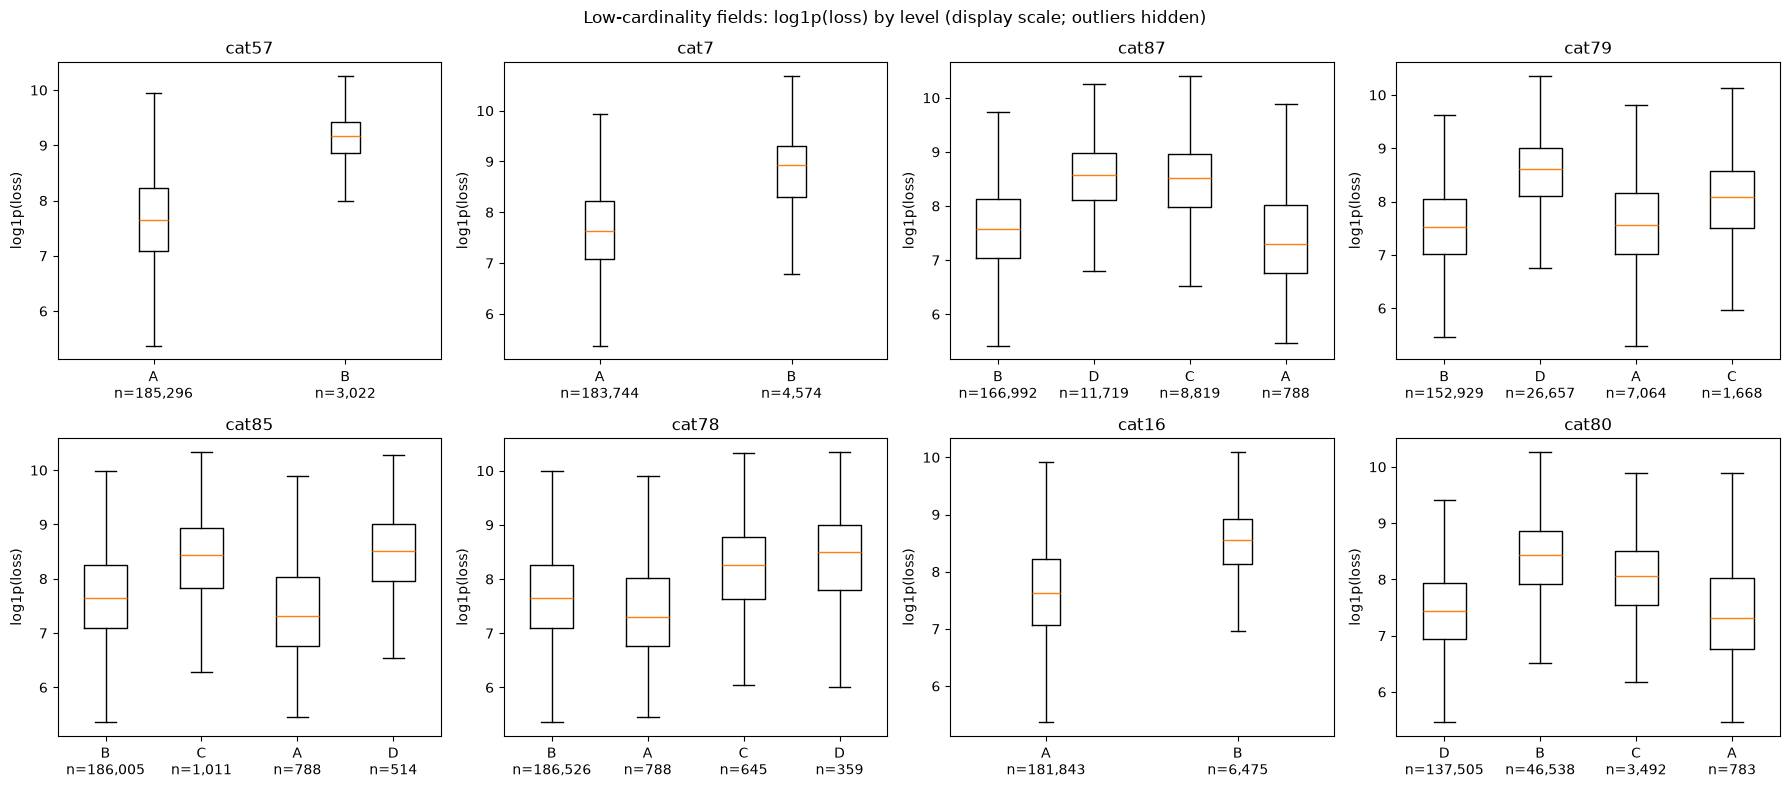

In [8]:
df["log1p_loss"] = np.log1p(df[TARGET])

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, field in zip(axes.ravel(), low_card_selected):
    levels = df[field].value_counts().index.tolist()
    data = [df.loc[df[field] == level, "log1p_loss"] for level in levels]

    ax.boxplot(
        data,
        tick_labels=[f"{lv}\nn={len(d):,}" for lv, d in zip(levels, data)],
        showfliers=False,
    )
    ax.set_title(field)
    ax.set_ylabel("log1p(loss)")

fig.suptitle(
    "Low-cardinality fields: log1p(loss) by level (display scale; outliers hidden)"
)
fig.tight_layout()
plt.show()

In [9]:
low_card_summary = (
    level_tables[level_tables["field"].isin(low_card_selected)]
    .set_index(["field", "level"])
)

print("Raw-unit summary for the plotted fields:")
display(low_card_summary)

Raw-unit summary for the plotted fields:


support     mean_loss  median_loss     std_loss   q25_loss  \
field level                                                               
cat7  A       183744   2908.944342     2073.635  2683.995880  1189.5400   
      B         4574   8195.078524     7614.575  5530.075731  4018.1225   
cat16 A       181843   2932.628091     2051.700  2810.792843  1181.0600   
      B         6475   5977.987375     5199.600  3801.805857  3419.7200   
cat57 A       185296   2919.869699     2081.930  2693.253931  1192.9875   
      B         3022  10239.967773     9532.340  5298.800662  6993.3675   
cat78 B       186526   3026.361566     2111.815  2886.886879  1203.6300   
      A          788   2616.591536     1486.840  2984.145451   862.7750   
      C          645   5050.549132     3892.640  4356.754434  2060.7000   
      D          359   6046.691978     4927.440  4853.036339  2445.1650   
cat79 B       152929   2469.844946     1858.840  2065.177452  1111.2800   
      D        26657   6311.832058     5440.810  4449.475321  3322.6300   
      A         7064   2718.406969     1932.090  2497.090410  1104.0150   
      C         1668   4086.994281     3264.555  3992.885665  1824.9225   
cat80 D       137505   2200.253191     1695.590  1771.822623  1039.8600   
      B        46538   5453.621252     4568.170  3983.249022  2753.1450   
      C         3492   3890.750095     3143.245  3403.392097  1884.7200   
      A          783   2621.223627     1489.670  2990.671853   862.2700   
cat85 B       186005   3016.017262     2107.350  2872.152649  1201.5600   
      C         1011   5762.211414     4607.670  4593.879439  2516.1800   
      A          788   2616.591536     1486.840  2984.145451   862.7750   
      D          514   6038.127529     4932.485  5059.971272  2852.7025   
cat87 B       166992   2667.135706     1934.570  2429.055727  1137.4700   
      D        11719   6134.342702     5270.120  4184.565356  3311.0600   
      C         8819   5969.474562     4967.840  4511.362583  2935.0550   
      A          788   2616.591536     1486.840  2984.145451   862.7750   

               q75_loss   iqr_loss  is_rare  
field level                                  
cat7  A       3734.6400  2545.1000    False  
      B      11052.2450  7034.1225    False  
cat16 A       3698.3350  2517.2750    False  
      B       7526.8750  4107.1550    False  
cat57 A       3748.3225  2555.3350    False  
      B      12418.2600  5424.8925    False  
cat78 B       3849.3350  2645.7050    False  
      A       3050.6550  2187.8800    False  
      C       6417.5600  4356.8600    False  
      D       8139.8300  5694.6650    False  
cat79 B       3151.6000  2040.3200    False  
      D       8197.5300  4874.9000    False  
      A       3474.3075  2370.2925    False  
      C       5323.3000  3498.3775    False  
cat80 D       2782.7300  1742.8700    False  
      B       7063.5875  4310.4425    False  
      C       4940.6075  3055.8875    False  
      A       3051.8100  2189.5400    False  
cat85 B       3836.6000  2635.0400    False  
      C       7539.9750  5023.7950    False  
      A       3050.6550  2187.8800    False  
      D       8237.8525  5385.1500    False  
cat87 B       3361.5750  2224.1050    False  
      D       7877.0750  4566.0150    False  
      C       7809.9050  4874.8500    False  
      A       3050.6550  2187.8800    False

## High-cardinality fields

`cat116`, `cat110`, and `cat109` have 326, 131, and 84 levels. Plotting every
label would be unreadable, so each field gets an ordered point view of its 20
most-supported levels, and the rare tail is summarized separately underneath.

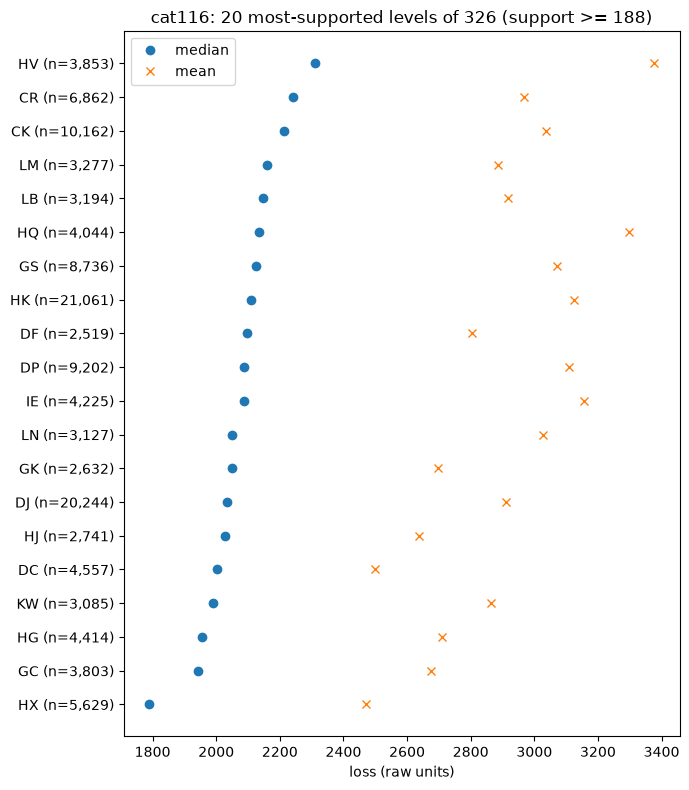

cat116 rare tail: 223 of 326 levels below 188 support, covering 6,673 rows (3.54%)
  rare-level loss   -> mean 3,652, median 2,287
  all rows          -> mean 3,037, median 2,116


,support,mean_loss,median_loss,std_loss,q25_loss,q75_loss,iqr_loss,is_rare
cat116,,,,,,,,
HX,5629,2472.334262,1788.670,2239.485458,1100.9700,3110.2100,2009.2400,False
GC,3803,2676.022987,1942.010,2311.115549,1087.9000,3501.1200,2413.2200,False
HG,4414,2709.464662,1955.390,2334.144596,1131.2125,3463.1600,2331.9475,False
KW,3085,2865.285235,1990.470,2789.979779,1213.6300,3483.9400,2270.3100,False
DC,4557,2499.712947,2001.800,1791.138895,1194.6700,3273.3600,2078.6900,False
HJ,2741,2637.211262,2027.460,2168.540795,1238.4200,3363.7900,2125.3700,False
DJ,20244,2911.900687,2032.920,2562.341762,1142.9800,3869.2950,2726.3150,False
GK,2632,2695.767964,2050.455,2131.372800,1180.7050,3570.9875,2390.2825,False
LN,3127,3025.990966,2050.640,3100.377909,1258.5650,3557.8350,2299.2700,False


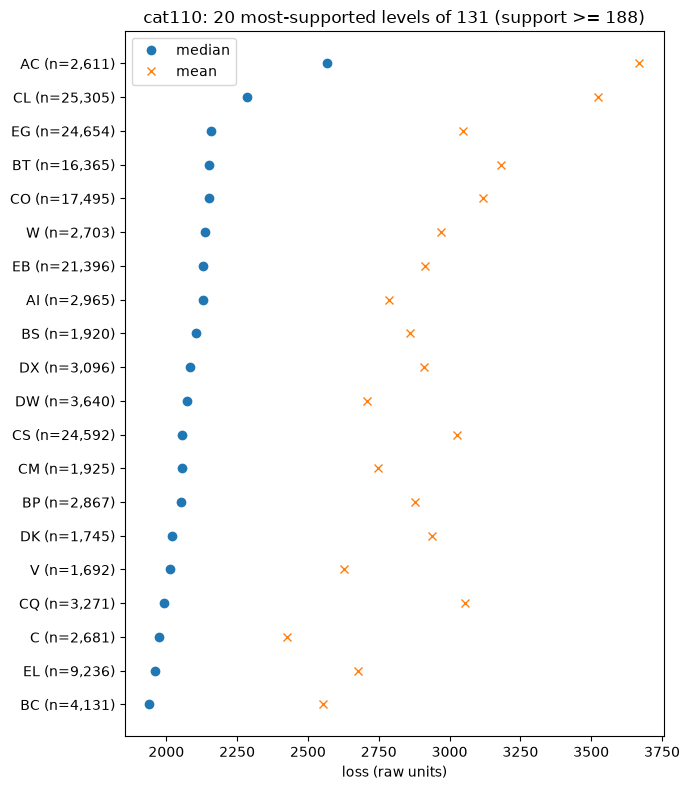

cat110 rare tail: 92 of 131 levels below 188 support, covering 2,916 rows (1.55%)
  rare-level loss   -> mean 2,526, median 1,837
  all rows          -> mean 3,037, median 2,116


,support,mean_loss,median_loss,std_loss,q25_loss,q75_loss,iqr_loss,is_rare
cat110,,,,,,,,
BC,4131,2554.964490,1939.760,2151.528924,1189.6950,3173.0600,1983.3650,False
EL,9236,2676.473775,1959.490,2817.729586,1142.2725,3405.6675,2263.3950,False
C,2681,2425.913122,1973.470,1699.755843,1158.9900,3276.9200,2117.9300,False
CQ,3271,3053.205075,1991.560,3032.288518,1118.9750,3813.6850,2694.7100,False
V,1692,2626.015709,2012.000,1983.830363,1090.4400,3705.1275,2614.6875,False
DK,1745,2938.172309,2020.680,2537.056515,1176.5900,3835.7300,2659.1400,False
BP,2867,2877.967789,2051.700,2716.918804,1161.2900,3534.0250,2372.7350,False
CM,1925,2747.197496,2056.020,2208.022617,1178.6300,3655.7300,2477.1000,False
CS,24592,3024.899151,2056.510,2850.364645,1180.7800,3841.1525,2660.3725,False


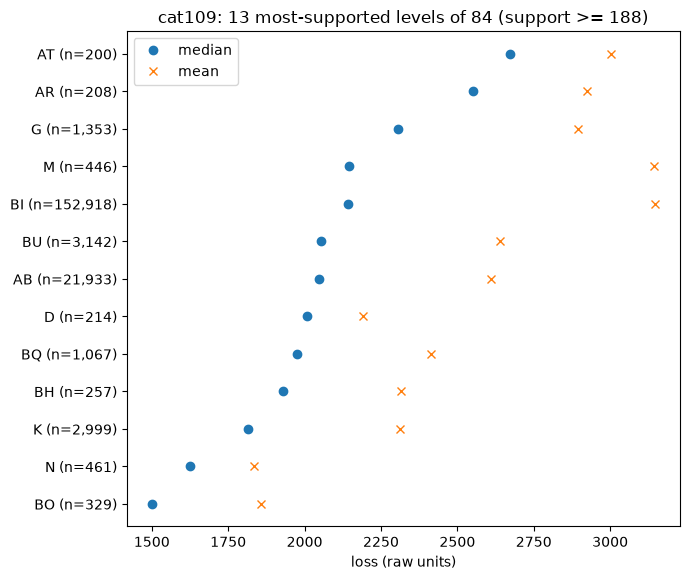

cat109 rare tail: 71 of 84 levels below 188 support, covering 2,791 rows (1.48%)
  rare-level loss   -> mean 2,426, median 1,872
  all rows          -> mean 3,037, median 2,116


,support,mean_loss,median_loss,std_loss,q25_loss,q75_loss,iqr_loss,is_rare
cat109,,,,,,,,
BO,329,1855.679574,1500.160,1279.411039,972.9800,2433.4900,1460.5100,False
N,461,1833.556659,1625.310,1040.829377,999.5700,2462.2500,1462.6800,False
K,2999,2313.398966,1816.350,1841.388467,1052.9250,3055.4650,2002.5400,False
BH,257,2315.350428,1930.470,1507.063244,1128.3700,3189.8300,2061.4600,False
BQ,1067,2415.129419,1974.420,1698.127753,1079.4700,3372.7400,2293.2700,False
D,214,2190.049813,2008.750,1210.793643,1197.1325,2984.3050,1787.1725,False
AB,21933,2609.727573,2048.220,1900.096355,1192.6400,3522.6300,2329.9900,False
BU,3142,2639.220869,2054.755,2102.608022,1242.9600,3324.8475,2081.8875,False
BI,152918,3146.284932,2141.130,3076.370083,1211.8075,3987.5875,2775.7800,False


In [10]:
HIGH_CARDINALITY_FIELDS = ["cat116", "cat110", "cat109"]
MAX_LEVELS_PLOTTED = 20


def high_cardinality_view(field):
    table = level_target_table(field)

    supported = (
        table[~table["is_rare"]]
        .nlargest(MAX_LEVELS_PLOTTED, "support")
        .sort_values("median_loss")
    )

    fig, ax = plt.subplots(figsize=(7, 0.3 * len(supported) + 2))
    positions = range(len(supported))
    ax.plot(supported["median_loss"], positions, "o", label="median")
    ax.plot(supported["mean_loss"], positions, "x", label="mean")
    ax.set_yticks(list(positions))
    ax.set_yticklabels(
        [f"{lv} (n={int(n):,})" for lv, n in zip(supported.index, supported["support"])]
    )
    ax.set_xlabel("loss (raw units)")
    ax.set_title(
        f"{field}: {len(supported)} most-supported levels "
        f"of {len(table)} (support >= {THRESHOLD})"
    )
    ax.legend()
    fig.tight_layout()
    plt.show()

    tail = table[table["is_rare"]]
    tail_rows = int(tail["support"].sum())

    print(
        f"{field} rare tail: {len(tail)} of {len(table)} levels below {THRESHOLD} support, "
        f"covering {tail_rows:,} rows ({tail_rows / len(df):.2%})"
    )
    if tail_rows:
        tail_mask = df[field].isin(tail.index)
        print(
            f"  rare-level loss   -> mean {df.loc[tail_mask, TARGET].mean():,.0f}, "
            f"median {df.loc[tail_mask, TARGET].median():,.0f}"
        )
        print(
            f"  all rows          -> mean {df[TARGET].mean():,.0f}, "
            f"median {df[TARGET].median():,.0f}"
        )

    return supported


for field in HIGH_CARDINALITY_FIELDS:
    display(high_cardinality_view(field))

## Encoding confirmation

Every statistic in this notebook is produced by grouping on the original level
labels. No `cat*` field is converted to an integer code, and no correlation,
ordinal, or distance statistic is applied to any `cat*` field - those would
impose an ordering on labels that carry none.

In [11]:
cat_dtypes_non_numeric = ~df[CAT_COLS].dtypes.map(pd.api.types.is_numeric_dtype)
frozen_levels = level_tables["level"].drop_duplicates()

encoding_checks = pd.Series({
    "no cat* field is stored as a number": bool(cat_dtypes_non_numeric.all()),
    "frozen level column holds original labels": bool(
        frozen_levels.map(lambda value: isinstance(value, str)).all()
    ),
})

display(encoding_checks.to_frame("passed"))
assert encoding_checks.all(), f"failed: {list(encoding_checks[~encoding_checks].index)}"

print("Categorical associations are computed from level labels only.")

,passed
no cat* field is stored as a number,True
frozen level column holds original labels,True


Categorical associations are computed from level labels only.
